<a href="https://colab.research.google.com/github/mail2venkie/fastbook/blob/temp/myclean/06_multicat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.6 MB/s eta 0:00:00
Mounted at /content/gdrive


In [2]:
#hide
from fastbook import *

In [3]:
from fastai.vision.all import *
path = untar_data(URLs.PASCAL_2007)
path.ls()

(#8) [Path('/root/.fastai/data/pascal_2007/train'),Path('/root/.fastai/data/pascal_2007/test'),Path('/root/.fastai/data/pascal_2007/train.csv'),Path('/root/.fastai/data/pascal_2007/train.json'),Path('/root/.fastai/data/pascal_2007/test.csv'),Path('/root/.fastai/data/pascal_2007/segmentation'),Path('/root/.fastai/data/pascal_2007/valid.json'),Path('/root/.fastai/data/pascal_2007/test.json')]

My trials
** START **

In [65]:
def get_x(df):
  return path/'train'/df['fname']

def get_y(df):
  return df['labels'].split(' ')

def splitter(df):
  train = df.index[~df['is_valid']].tolist()
  valid = df.index[df['is_valid']].tolist()
  return train, valid

In [36]:
df = pd.read_csv(path/'train.csv')
df[0:10]

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True
5,000017.jpg,person horse,False
6,000019.jpg,cat,True
7,000020.jpg,car,True
8,000021.jpg,dog person,True
9,000023.jpg,bicycle person,False


In [66]:
dblk = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_x=get_x,
    get_y=get_y,
    splitter=splitter,
    item_tfms=RandomResizedCrop(128, min_scale=0.35)
)
dls = dblk.dataloaders(df)

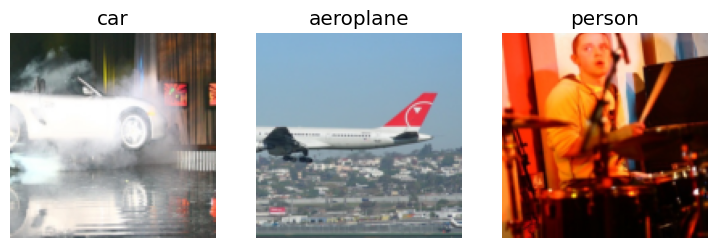

In [67]:
dls.show_batch(nrows=1, ncols=3)

In [87]:
dsets = dblk.datasets(df)
dsets.train.vocab, len(dsets.train.vocab)

(['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'],
 20)

In [81]:
learner = None
learner = vision_learner(dls=dls, arch=resnet18, metrics=error_rate)

In [82]:
x,y= to_cpu(dls.one_batch())
activations = learner.model(x)
activations

TensorImage([[ 1.4582, -0.4066, -0.1614,  ..., -0.4531, -0.0452, -3.1699],
             [ 1.4154, -1.0802,  1.4999,  ..., -4.8779,  2.4697, -3.1087],
             [-2.7670,  0.6654, -2.2079,  ..., -0.1140,  0.5792,  0.5160],
             ...,
             [ 1.7643, -0.8185, -0.8733,  ..., -0.4766,  0.2792,  2.3239],
             [-1.6500,  0.0546,  1.6702,  ..., -0.5133,  0.3960,  4.9499],
             [ 0.8455,  1.1311,  1.8725,  ..., -0.8923,  1.2467,  0.4642]], grad_fn=<AliasBackward0>)

In [86]:
activations.shape

torch.Size([64, 20])

TensorImage([[0.8113, 0.3997, 0.4597,  ..., 0.3886, 0.4887, 0.0403],
             [0.8046, 0.2535, 0.8176,  ..., 0.0076, 0.9220, 0.0428],
             [0.0591, 0.6605, 0.0990,  ..., 0.4715, 0.6409, 0.6262],
             ...,
             [0.8537, 0.3061, 0.2946,  ..., 0.3831, 0.5694, 0.9108],
             [0.1611, 0.5137, 0.8416,  ..., 0.3744, 0.5977, 0.9930],
             [0.6996, 0.7560, 0.8667,  ..., 0.2906, 0.7767, 0.6140]], grad_fn=<AliasBackward0>)